In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rizwanaliza/cleandataset/clean_dataset.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dataset = pd.read_csv('/kaggle/input/datasets/rizwanaliza/cleandataset/clean_dataset.csv')

In [4]:
dataset.head(10)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,88,0,1,1,2,1,3850,239,1,1
1,0,82,0,0,1,3,0,3588,154,2,1
2,1,101,0,1,1,2,0,2483,198,2,1
3,0,70,0,0,1,2,1,3385,217,3,1
4,0,100,1,0,1,3,0,3394,113,2,1
5,1,102,0,0,1,2,1,3448,163,1,1
6,1,95,1,1,1,2,0,588,147,2,1
7,0,90,0,0,0,2,1,1951,101,2,1
8,0,80,0,0,1,2,0,912,154,0,1
9,0,99,0,0,1,2,1,126,115,0,1


In [5]:
X = dataset.drop('stroke',axis=1)
y = dataset['stroke']

In [6]:
X.head(10)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,1,88,0,1,1,2,1,3850,239,1
1,0,82,0,0,1,3,0,3588,154,2
2,1,101,0,1,1,2,0,2483,198,2
3,0,70,0,0,1,2,1,3385,217,3
4,0,100,1,0,1,3,0,3394,113,2
5,1,102,0,0,1,2,1,3448,163,1
6,1,95,1,1,1,2,0,588,147,2
7,0,90,0,0,0,2,1,1951,101,2
8,0,80,0,0,1,2,0,912,154,0
9,0,99,0,0,1,2,1,126,115,0


# Feature Selection

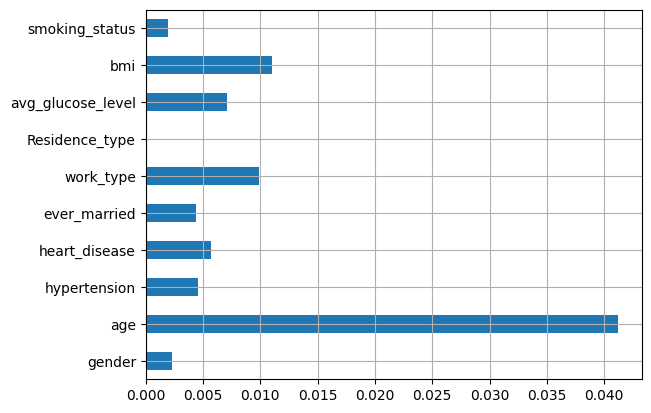

In [7]:
from sklearn.feature_selection import mutual_info_classif
important = mutual_info_classif(X,y)
features_important= pd.Series(important,dataset.columns[0 : len(dataset.columns)-1])
features_important.plot(kind='barh')
plt.grid(True)
plt.show()




In [8]:
low_importantFeatures = features_important[features_important < 0.005]
low_importantFeatures

gender            0.002255
hypertension      0.004589
ever_married      0.004397
Residence_type    0.000000
smoking_status    0.001952
dtype: float64

In [9]:
high_importantFeatures = features_important[features_important >= 0.005]
high_importantFeatures

age                  0.041219
heart_disease        0.005735
work_type            0.009842
avg_glucose_level    0.007055
bmi                  0.011020
dtype: float64

In [10]:
### Apply Feature Selection
# first, I specify the Lasso Regression model, and I
# select a suitable alpha (equivalent of penalty).
# The bigger the alpha the less features that will be selected.

# Then I use the selectFromModel object from sklearn, which
# will select the features which coefficients are non-zero

from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel

features_selection = SelectFromModel(Lasso(alpha=0.005, random_state=0))
features_selection.fit(X,y)


SelectFromModel(estimator=Lasso(alpha=0.005, random_state=0))

In [11]:
features_selection.get_support()

array([False,  True, False, False, False,  True, False,  True,  True,
        True])

In [12]:
selectFeatures = X.columns[features_selection.get_support()]

In [13]:
selectFeatures

Index(['age', 'work_type', 'avg_glucose_level', 'bmi', 'smoking_status'], dtype='object')

# Dataset Regeneration With Selected Features

In [14]:
X = pd.DataFrame({'age':dataset['age'], 'work_type': dataset['work_type'],'avg_glucose_level':dataset['avg_glucose_level'],'bmi':dataset['bmi'], 'smoking_status': dataset['smoking_status'], })

In [15]:
X.head(10)

,age,work_type,avg_glucose_level,bmi,smoking_status
0,88,2,3850,239,1
1,82,3,3588,154,2
2,101,2,2483,198,2
3,70,2,3385,217,3
4,100,3,3394,113,2
5,102,2,3448,163,1
6,95,2,588,147,2
7,90,2,1951,101,2
8,80,2,912,154,0
9,99,2,126,115,0


# OverSampling

In [16]:
from imblearn.over_sampling import SMOTE
sample = SMOTE()
X_resample, y_resample= sample.fit_resample(X,y)

In [17]:
y_resample.value_counts()

stroke
1    4861
0    4861
Name: count, dtype: int64

In [18]:
X = X_resample
y = y_resample

In [19]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=0)

In [20]:
X_train.shape

(7777, 5)

In [21]:
y_train.shape

(7777,)

In [22]:
X_test.shape

(1945, 5)

# Data Normalization 

In [23]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Machine Learning

# RandomForest

In [24]:

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators = 100, random_state = 0)
rf.fit(X_train,y_train)
y_predict = rf.predict(X_test)

# Final Results

In [25]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_predict)
print("accuracy is", accuracy*100,"%")

accuracy is 91.36246786632391 %


In [26]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_predict))


              precision    recall  f1-score   support

           0       0.94      0.88      0.91       973
           1       0.89      0.94      0.92       972

    accuracy                           0.91      1945
   macro avg       0.92      0.91      0.91      1945
weighted avg       0.92      0.91      0.91      1945



In [27]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
print('Mean Absolute Error:', mean_absolute_error(y_test, y_predict))
print('Mean Squared Error:', mean_squared_error(y_test, y_predict))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, y_predict)))


Mean Absolute Error: 0.08637532133676093
Mean Squared Error: 0.08637532133676093
Root Mean Squared Error: 0.29389678687723164


Text(50.722222222222214, 0.5, 'Actual Label')

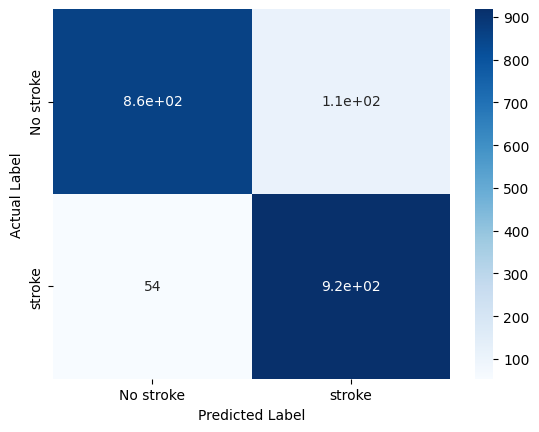

In [28]:
from sklearn.metrics import confusion_matrix
x_axis = ['No stroke','stroke']
y_axis = ['No stroke','stroke']

cm=confusion_matrix(y_test,y_predict)
sns.heatmap(cm, annot=True,cmap='Blues', xticklabels=x_axis, yticklabels=y_axis)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

In [29]:
result = pd.DataFrame({'Actual Value': y_test , 'Predicted Values': y_predict})
result.head(10)

,Actual Value,Predicted Values
2913,0,0
8359,1,1
7966,1,1
6381,1,1
5112,1,1
6323,1,1
5276,1,1
9023,1,1
3852,0,0
2717,0,0
